In [47]:
%matplotlib inline

In [48]:
import os
import glob
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# הגדרת התקן (Device)
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# פרמטרים לאימון
BATCH_SIZE = 8       # אם הזיכרון נחנק, הורד ל-4
LEARNING_RATE = 0.0002
EPOCHS = 101
IMG_SIZE = 256
LAMBDA_L1 = 100      # כמה משקל לתת לדיוק הפיקסלים מול הריאליזם
DATA_DIR = "/tf/clock_project/alnalog_clock/dataset_generator/dataset/inpainting" # וודא שהנתיב תואם למבנה שלך
MASK_WEIGHT = 50.0

Using device: cuda


In [49]:
class ClockInpaintingDataset(Dataset):
    def __init__(self, root_dir, mode='train', transform=None):
        self.root_dir = root_dir
        self.transform = transform
        
        # נתיבים (הנחה: הגנרטור שלך שומר במבנה הזה)
        self.source_dir = os.path.join(root_dir, mode, 'source') # תמונה עם מחוגים
        self.mask_dir = os.path.join(root_dir, mode, 'mask')     # מסכה (לבן=מחוג, שחור=רקע)
        self.target_dir = os.path.join(root_dir, mode, 'target') # רקע נקי
        
        self.files = sorted([f for f in os.listdir(self.source_dir) if f.endswith(('.png', '.jpg'))])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]
        
        # טעינה
        src_img = Image.open(os.path.join(self.source_dir, filename)).convert('RGB')
        mask_img = Image.open(os.path.join(self.mask_dir, filename)).convert('L') # L = Grayscale
        tgt_img = Image.open(os.path.join(self.target_dir, filename)).convert('RGB')
        
        # טרנספורמציות
        if self.transform:
            src = self.transform(src_img)
            mask = self.transform(mask_img) # המסכה תהיה בטווח [-1, 1] או [0, 1] תלוי בנרמול
            tgt = self.transform(tgt_img)
            
            # תיקון למסכה: אנחנו רוצים אותה בטווח [0, 1] בבירור עבור החישובים
            # אם הטרנספורמציה נרמלה ל-[-1, 1], נחזיר ל-[0, 1]
            mask = (mask + 1) / 2 
            # בינאריזציה מוחלטת (למנוע ערכי ביניים בקצוות)
            mask = (mask > 0.5).float()

        return src, mask, tgt

# הגדרות טרנספורמציה
transforms_ = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # מנרמל ל-[-1, 1]
])

# DataLoader
train_dataset = ClockInpaintingDataset(DATA_DIR, mode='train', transform=transforms_)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)

In [50]:
# --- Generator (U-Net) ---
class InpaintGenerator(nn.Module):
    def __init__(self, in_channels=4, out_channels=3): # 4 ערוצים בכניסה!
        super(InpaintGenerator, self).__init__()

        def down_block(in_feat, out_feat, normalize=True):
            layers = [nn.Conv2d(in_feat, out_feat, 4, 2, 1, bias=False)]
            if normalize:
                layers.append(nn.InstanceNorm2d(out_feat))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        def up_block(in_feat, out_feat, dropout=0.0):
            layers = [
                nn.ConvTranspose2d(in_feat, out_feat, 4, 2, 1, bias=False),
                nn.InstanceNorm2d(out_feat),
                nn.ReLU(inplace=True)
            ]
            if dropout:
                layers.append(nn.Dropout(dropout))
            return layers

        # Encoder
        self.down1 = nn.Sequential(*down_block(in_channels, 64, normalize=False))
        self.down2 = nn.Sequential(*down_block(64, 128))
        self.down3 = nn.Sequential(*down_block(128, 256))
        self.down4 = nn.Sequential(*down_block(256, 512, normalize=False)) # Bottleneck
        
        # Decoder
        self.up1 = nn.Sequential(*up_block(512, 256))
        self.up2 = nn.Sequential(*up_block(512, 128)) # Skip connection doubles input
        self.up3 = nn.Sequential(*up_block(256, 64))
        
        self.final = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(128, out_channels, 4, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        # x shape: (Batch, 4, 256, 256)
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        
        u1 = self.up1(d4)
        u2 = self.up2(torch.cat([u1, d3], 1)) # Skip
        u3 = self.up3(torch.cat([u2, d2], 1)) # Skip
        
        return self.final(torch.cat([u3, d1], 1))

In [51]:
# --- Discriminator (PatchGAN) ---
class InpaintDiscriminator(nn.Module):
    def __init__(self, in_channels=7): # 4 input + 3 output = 7 channels
        super(InpaintDiscriminator, self).__init__()

        def discriminator_block(in_filters, out_filters, normalization=True):
            layers = [nn.Conv2d(in_filters, out_filters, 4, stride=2, padding=1)]
            if normalization:
                layers.append(nn.InstanceNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *discriminator_block(in_channels, 64, normalization=False),
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(256, 1, 4, padding=1, bias=False)
        )

    def forward(self, img_input, img_target):
        # img_input: (Batch, 4, H, W) - Source + Mask
        # img_target: (Batch, 3, H, W) - Real Clean or Fake Clean
        d_in = torch.cat((img_input, img_target), 1)
        return self.model(d_in)

In [52]:
from IPython.display import clear_output

def sample_images(dataloader, generator, epoch, i):
    generator.eval() # מצב חיזוי
    
    with torch.no_grad():
        imgs = next(iter(dataloader))
        real_src = imgs[0].to(device)
        mask = imgs[1].to(device)
        real_tgt = imgs[2].to(device)
        
        gen_input = torch.cat((real_src, mask), 1)
        fake_clean = generator(gen_input)
        
        # ניקוי הפלט הקודם כדי ליצור אפקט של אנימציה
        clear_output(wait=True)
        
        # יצירת הגרף
        plt.figure(figsize=(15, 5))
        images_tensor = [real_src, mask, fake_clean, real_tgt]
        titles = ['Source (With Hands)', 'Mask', 'Generated (Clean)', 'Real Target']
        
        for idx, img_tensor in enumerate(images_tensor):
            ax = plt.subplot(1, 4, idx+1)
            img = img_tensor[0].detach().cpu()
            
            if img.shape[0] == 1: # מסכה
                img_np = img.squeeze(0).numpy()
                ax.imshow(img_np, cmap='gray')
            else: # תמונה צבעונית
                img_np = img.permute(1, 2, 0).numpy()
                img_np = (img_np * 0.5) + 0.5
                ax.imshow(np.clip(img_np, 0, 1))
                
            ax.set_title(titles[idx])
            ax.axis('off')
        
        plt.tight_layout()
        plt.show() # פקודה זו מציגה את הגרף
        
        # הדפסת מידע טקסטואלי *אחרי* התמונה (כדי שלא יימחק)
        print(f"--- Epoch {epoch} Result Sample ---")

    generator.train() # חזרה למצב אימון

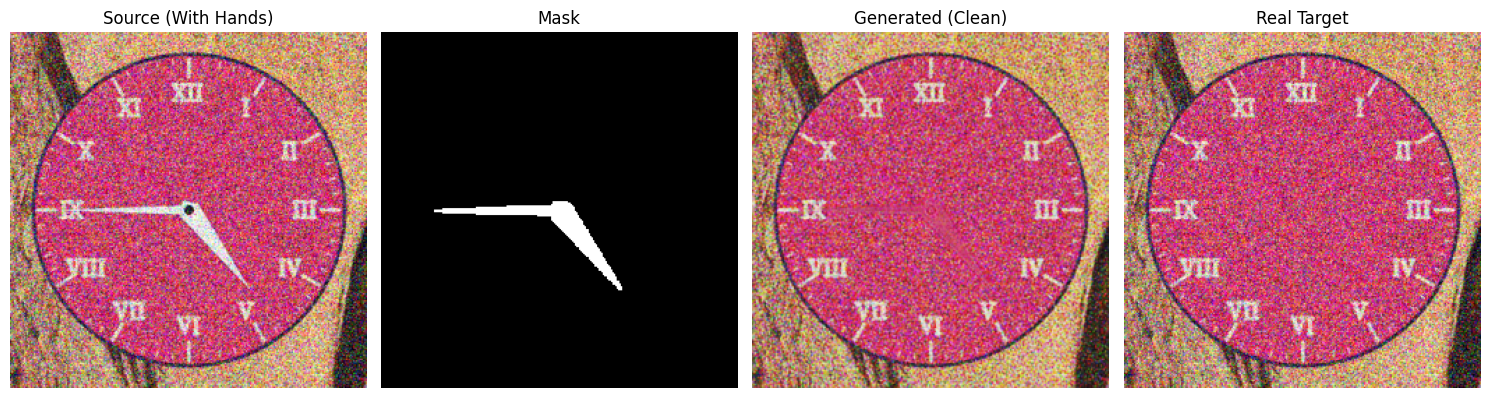

--- Epoch 24 Result Sample ---
[Epoch 25/101] [Batch 0] [D loss: 0.0002] [G loss: 8.3026]
[Epoch 25/101] [Batch 500] [D loss: 0.0004] [G loss: 15.9694]
[Epoch 25/101] [Batch 1000] [D loss: 0.0003] [G loss: 7.5197]
[Epoch 25/101] [Batch 1500] [D loss: 0.0004] [G loss: 10.9354]
[Epoch 25/101] [Batch 2000] [D loss: 0.0002] [G loss: 10.2096]


In [ ]:
# יצירת המודלים
generator = InpaintGenerator().to(device)
discriminator = InpaintDiscriminator().to(device)

# אתחול משקולות
generator.apply(weights_init_normal)
discriminator.apply(weights_init_normal)

# פונקציות מחיר
criterion_GAN = nn.MSELoss()
criterion_pixel = nn.L1Loss(reduction='none') # שומר על דמיון לתמונת היעד

# אופטימייזרים
optimizer_G = torch.optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))

# --- Training Loop (Fixed) ---

print(f"Starting Training (With Visualization)...")

for epoch in range(EPOCHS):
    for i, batch in enumerate(train_loader):
        
        # טעינת נתונים
        real_src = batch[0].to(device) 
        mask = batch[1].to(device)     
        real_tgt = batch[2].to(device) 
        
        gen_input = torch.cat((real_src, mask), 1)

        # ------------------
        #  Train Generator
        # ------------------
        optimizer_G.zero_grad()

        fake_clean = generator(gen_input)
        pred_fake = discriminator(gen_input, fake_clean)
        
        valid = torch.ones_like(pred_fake, requires_grad=False).to(device)
        fake = torch.zeros_like(pred_fake, requires_grad=False).to(device)

        # GAN Loss
        loss_GAN = criterion_GAN(pred_fake, valid)

        # Weighted Inpainting Loss
        pixel_diff = torch.abs(fake_clean - real_tgt)
        weighted_pixel_loss = pixel_diff * (mask * MASK_WEIGHT + (1 - mask))
        loss_pixel = weighted_pixel_loss.mean()

        # Total G Loss
        loss_G = loss_GAN + (LAMBDA_L1 * loss_pixel)

        loss_G.backward()
        optimizer_G.step()

        # ---------------------
        #  Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()

        pred_real = discriminator(gen_input, real_tgt)
        loss_real = criterion_GAN(pred_real, valid)

        pred_fake = discriminator(gen_input, fake_clean.detach())
        loss_fake = criterion_GAN(pred_fake, fake)

        loss_D = 0.5 * (loss_real + loss_fake)

        loss_D.backward()
        optimizer_D.step()

        # הדפסה לוג
        if i % 500 == 0:
            print(f"[Epoch {epoch}/{EPOCHS}] [Batch {i}] [D loss: {loss_D.item():.4f}] [G loss: {loss_G.item():.4f}]")

    # --- ויזואליזציה בסוף כל Epoch ---
    # מציג דוגמה כדי שתוכל לראות איך המחיקה משתפרת
    print(f"\n--- Epoch {epoch} Result Sample ---")
    sample_images(train_loader, generator, epoch, i)
    
    # שמירה
    if epoch % 10 == 0:
        torch.save(generator.state_dict(), f"inpaint_gen_{epoch}.pth")
        print(f"Model saved: inpaint_gen_{epoch}.pth")